FEATURE ENGINEERING

Original Dataset: 70,000 rows × 26 columns

CREATING BUSINESS-DRIVEN FEATURES

✓ CLV_Proxy created (TotalCharges)
✓ ARPU (Average Revenue Per User) created
✓ ChargesRatio created
✓ EngagementScore created
✓ RiskScore created
✓ SatisfactionIndex created
✓ TenureCategory created
✓ AgeGroup created
✓ ChargesCategory created
✓ UsageIntensity created
✓ ServiceAdoptionScore created
✓ PaymentReliability created
✓ InteractionRecency created
✓ ContractValueScore created
✓ HasPremiumServices created
✓ HasStreamingServices created
✓ TotalServicesCount created
✓ ChargesPerProduct created
✓ SupportIntensity created
✓ LatePaymentRate created

✓ Total new features created: 20
✓ New dataset shape: 70,000 rows × 46 columns

NEW FEATURES SUMMARY

Numerical Features Statistics:
       CLV_Proxy      ARPU  ChargesRatio  EngagementScore  RiskScore  \
count   63047.00  63047.00      63047.00         70000.00   70000.00   
mean     1509.86     49.22          0.75            48.31      10

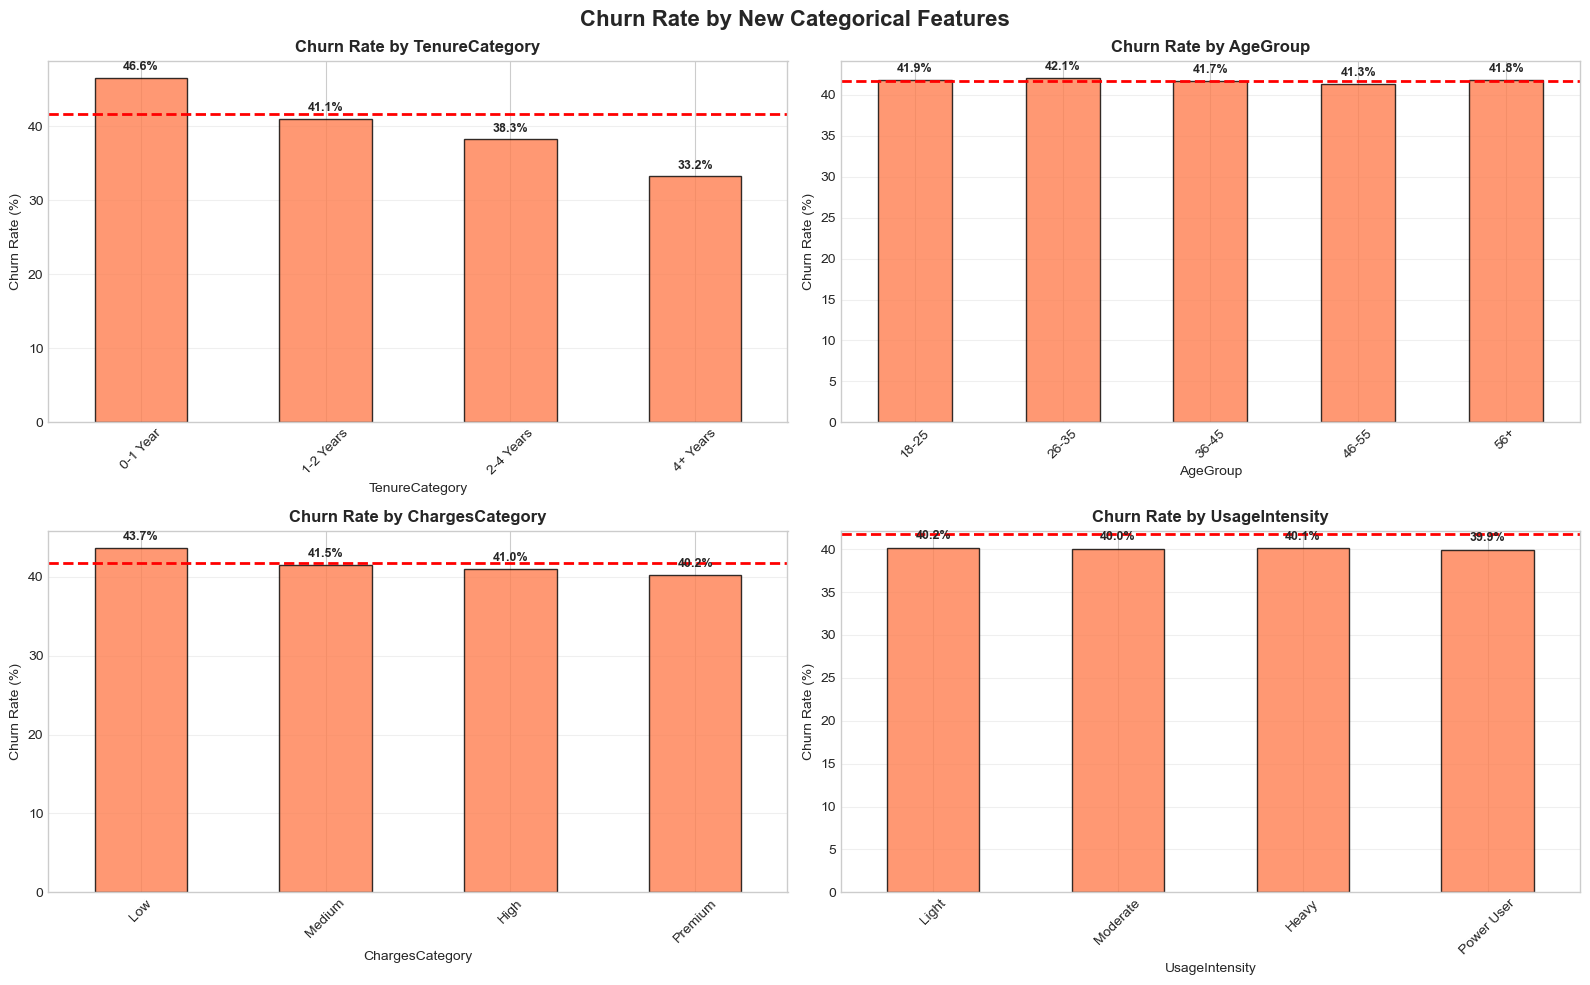


CORRELATION ANALYSIS - NEW FEATURES

Correlation with Churn (Top 10):
RiskScore               0.110
LatePaymentRate         0.091
SupportIntensity        0.089
ChargesPerProduct       0.054
ChargesRatio            0.031
ServiceAdoptionScore   -0.005
ARPU                   -0.026
HasStreamingServices   -0.061
CLV_Proxy              -0.065
PaymentReliability     -0.074
Name: Churn, dtype: float64

Correlation with Churn (Bottom 10):
ARPU                   -0.026
HasStreamingServices   -0.061
CLV_Proxy              -0.065
PaymentReliability     -0.074
TotalServicesCount     -0.077
InteractionRecency     -0.079
HasPremiumServices     -0.090
EngagementScore        -0.112
SatisfactionIndex      -0.127
ContractValueScore        NaN
Name: Churn, dtype: float64


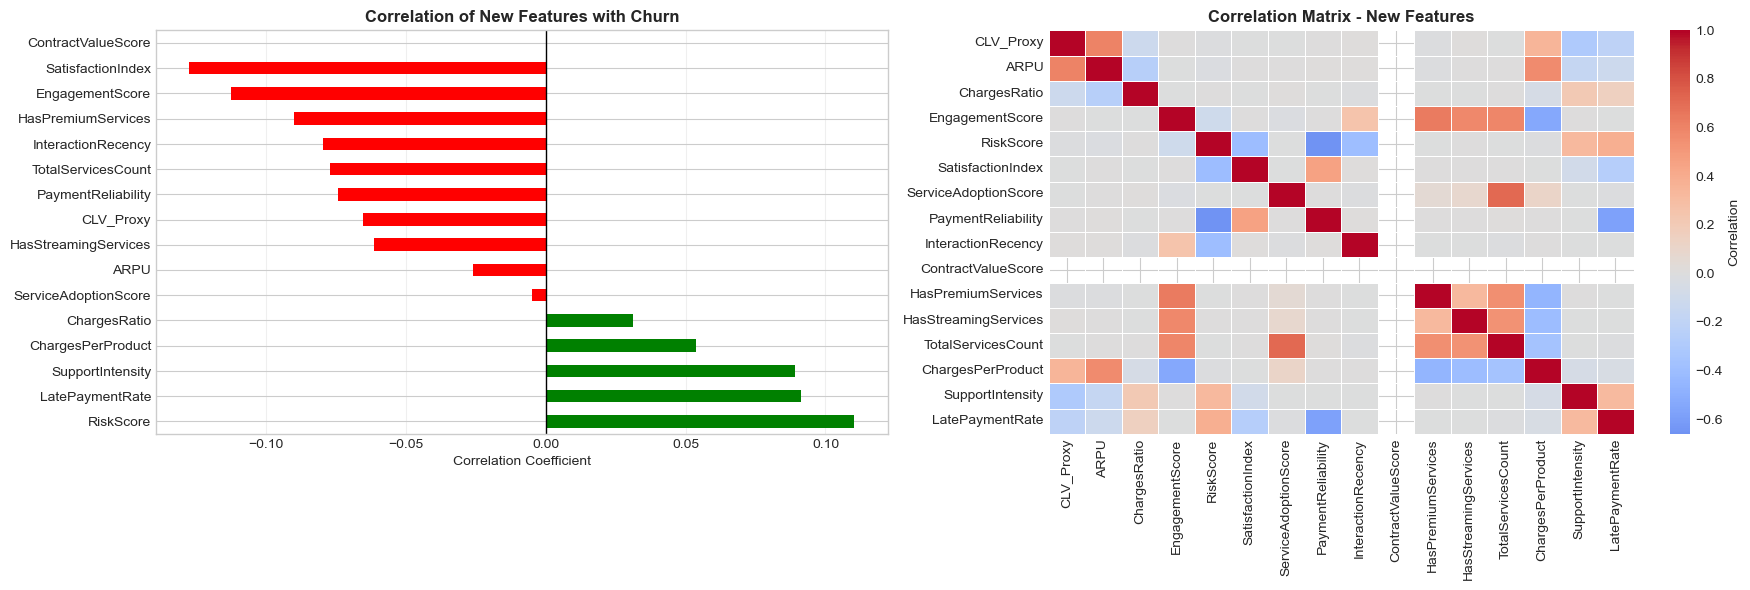


ENCODING CATEGORICAL VARIABLES
✓ Binary encoding applied to: ['PhoneService', 'PaperlessBilling']
✓ Multi-level encoding applied to: ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'TechSupport', 'StreamingTV', 'StreamingMovies']
✓ Label encoding applied to: ['Gender', 'ContractType', 'InternetService', 'PaymentMethod']
✓ One-hot encoding applied to: City (9 new columns)
✓ Encoding applied to new categorical features

✓ Encoded dataset shape: 70,000 rows × 63 columns

FEATURE SCALING
✓ StandardScaler applied to 26 numerical features
✓ Scaled dataset shape: 70,000 rows × 63 columns

SAVING PROCESSED DATA

FEATURE ENGINEERING SUMMARY
Original Features: 26
New Features Created: 20
Total Features: 46
Encoded Features: 63
Scaled Features: 63
Total Samples: 70,000

FEATURE ENGINEERING COMPLETED


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# NOTEBOOK 06: FEATURE ENGINEERING
# Purpose: Create new features and prepare data for modeling
# ═══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
pd.set_option('display.max_columns', None)

# ═══════════════════════════════════════════════════════════════════════════════
# 1. LOAD DATA
# ═══════════════════════════════════════════════════════════════════════════════

df = pd.read_csv('../data/raw/customer_churn_dataset.csv')

print("="*80)
print("FEATURE ENGINEERING")
print("="*80)
print(f"\nOriginal Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

# ═══════════════════════════════════════════════════════════════════════════════
# 2. BUSINESS-DRIVEN FEATURES
# ═══════════════════════════════════════════════════════════════════════════════

print("="*80)
print("CREATING BUSINESS-DRIVEN FEATURES")
print("="*80)

# 2.1 Customer Lifetime Value (CLV) Proxy
df['CLV_Proxy'] = df['TotalCharges']
print("\n✓ CLV_Proxy created (TotalCharges)")

# 2.2 Average Revenue Per Month
df['ARPU'] = df['TotalCharges'] / (df['TenureMonths'] + 1)  # +1 to avoid division by zero
print("✓ ARPU (Average Revenue Per User) created")

# 2.3 Charges Ratio (Monthly vs Total)
df['ChargesRatio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)
print("✓ ChargesRatio created")

# 2.4 Engagement Score (based on usage and products)
df['EngagementScore'] = (
    df['AvgMonthlyUsageGB'] / df['AvgMonthlyUsageGB'].max() * 0.4 +
    df['NumProducts'] / df['NumProducts'].max() * 0.3 +
    (1 - df['DaysSinceLastInteraction'] / df['DaysSinceLastInteraction'].max()) * 0.3
) * 100
print("✓ EngagementScore created")

# 2.5 Risk Score (based on negative indicators)
df['RiskScore'] = (
    df['SupportCalls'] / df['SupportCalls'].max() * 0.3 +
    df['LatePayments'] / df['LatePayments'].max() * 0.4 +
    df['DaysSinceLastInteraction'] / df['DaysSinceLastInteraction'].max() * 0.3
) * 100
print("✓ RiskScore created")

# 2.6 Customer Satisfaction Index
df['SatisfactionIndex'] = (
    df['SatisfactionScore'] / 5 * 0.6 +
    (1 - df['SupportCalls'] / df['SupportCalls'].max()) * 0.2 +
    (1 - df['LatePayments'] / df['LatePayments'].max()) * 0.2
) * 100
print("✓ SatisfactionIndex created")

# 2.7 Tenure Categories
df['TenureCategory'] = pd.cut(df['TenureMonths'], 
                               bins=[0, 12, 24, 48, 100], 
                               labels=['0-1 Year', '1-2 Years', '2-4 Years', '4+ Years'])
print("✓ TenureCategory created")

# 2.8 Age Groups
df['AgeGroup'] = pd.cut(df['Age'], 
                        bins=[0, 25, 35, 45, 55, 100], 
                        labels=['18-25', '26-35', '36-45', '46-55', '56+'])
print("✓ AgeGroup created")

# 2.9 Monthly Charges Categories
df['ChargesCategory'] = pd.cut(df['MonthlyCharges'], 
                                bins=[0, 30, 60, 90, 150], 
                                labels=['Low', 'Medium', 'High', 'Premium'])
print("✓ ChargesCategory created")

# 2.10 Usage Intensity
df['UsageIntensity'] = pd.cut(df['AvgMonthlyUsageGB'], 
                               bins=[0, 10, 30, 60, 200], 
                               labels=['Light', 'Moderate', 'Heavy', 'Power User'])
print("✓ UsageIntensity created")

# 2.11 Service Adoption Score (number of additional services)
service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
                'OnlineBackup', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['ServiceAdoptionScore'] = df[service_cols].apply(
    lambda x: sum([1 for val in x if val not in ['No', 'No internet service']]), axis=1
)
print("✓ ServiceAdoptionScore created")

# 2.12 Payment Reliability Score
df['PaymentReliability'] = 100 - (df['LatePayments'] / df['LatePayments'].max() * 100)
print("✓ PaymentReliability created")

# 2.13 Interaction Recency (inverse of DaysSinceLastInteraction)
df['InteractionRecency'] = 100 - (df['DaysSinceLastInteraction'] / df['DaysSinceLastInteraction'].max() * 100)
print("✓ InteractionRecency created")

# 2.14 Contract Value Score
contract_mapping = {'Month-to-month': 1, 'One year': 2, 'Two year': 3}
df['ContractValueScore'] = df['ContractType'].map(contract_mapping)
print("✓ ContractValueScore created")

# 2.15 Has Premium Services (binary)
df['HasPremiumServices'] = ((df['OnlineSecurity'] == 'Yes') | 
                             (df['OnlineBackup'] == 'Yes') | 
                             (df['TechSupport'] == 'Yes')).astype(int)
print("✓ HasPremiumServices created")

# 2.16 Has Streaming Services (binary)
df['HasStreamingServices'] = ((df['StreamingTV'] == 'Yes') | 
                               (df['StreamingMovies'] == 'Yes')).astype(int)
print("✓ HasStreamingServices created")

# 2.17 Total Services Count
df['TotalServicesCount'] = df['NumProducts'] + df['ServiceAdoptionScore']
print("✓ TotalServicesCount created")

# 2.18 Charges per Product
df['ChargesPerProduct'] = df['MonthlyCharges'] / (df['NumProducts'] + 1)
print("✓ ChargesPerProduct created")

# 2.19 Support Intensity (calls per month)
df['SupportIntensity'] = df['SupportCalls'] / (df['TenureMonths'] + 1)
print("✓ SupportIntensity created")

# 2.20 Late Payment Rate
df['LatePaymentRate'] = df['LatePayments'] / (df['TenureMonths'] + 1)
print("✓ LatePaymentRate created")

print(f"\n✓ Total new features created: 20")
print(f"✓ New dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

# ═══════════════════════════════════════════════════════════════════════════════
# 3. FEATURE IMPORTANCE PREVIEW
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("NEW FEATURES SUMMARY")
print("="*80)

new_features = ['CLV_Proxy', 'ARPU', 'ChargesRatio', 'EngagementScore', 'RiskScore',
                'SatisfactionIndex', 'ServiceAdoptionScore', 'PaymentReliability',
                'InteractionRecency', 'ContractValueScore', 'HasPremiumServices',
                'HasStreamingServices', 'TotalServicesCount', 'ChargesPerProduct',
                'SupportIntensity', 'LatePaymentRate']

print("\nNumerical Features Statistics:")
print(df[new_features].describe().round(2))

# ═══════════════════════════════════════════════════════════════════════════════
# 4. VISUALIZATION - NEW FEATURES vs CHURN
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("VISUALIZING NEW FEATURES vs CHURN")
print("="*80)


# 4.2 Categorical features
categorical_new = ['TenureCategory', 'AgeGroup', 'ChargesCategory', 'UsageIntensity']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for idx, col in enumerate(categorical_new):
    churn_rate = df.groupby(col)['Churn'].mean() * 100
    churn_rate.plot(kind='bar', ax=axes[idx], color='coral', edgecolor='black', alpha=0.8)
    axes[idx].set_title(f'Churn Rate by {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Churn Rate (%)', fontsize=10)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(axis='y', alpha=0.3)
    axes[idx].axhline(df['Churn'].mean() * 100, color='red', linestyle='--', linewidth=2)
    
    for i, v in enumerate(churn_rate.values):
        axes[idx].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Churn Rate by New Categorical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/results/06_categorical_features_churn.png', dpi=300, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 5. CORRELATION ANALYSIS - NEW FEATURES
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("CORRELATION ANALYSIS - NEW FEATURES")
print("="*80)

correlation_with_churn = df[new_features + ['Churn']].corr()['Churn'].drop('Churn').sort_values(ascending=False)

print("\nCorrelation with Churn (Top 10):")
print(correlation_with_churn.head(10).round(3))

print("\nCorrelation with Churn (Bottom 10):")
print(correlation_with_churn.tail(10).round(3))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar plot - correlation with churn
correlation_with_churn.plot(kind='barh', ax=axes[0], color=['red' if x < 0 else 'green' for x in correlation_with_churn.values])
axes[0].set_title('Correlation of New Features with Churn', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Correlation Coefficient', fontsize=10)
axes[0].grid(axis='x', alpha=0.3)
axes[0].axvline(0, color='black', linewidth=1)

# Heatmap - correlation matrix
corr_matrix = df[new_features].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, ax=axes[1], 
            cbar_kws={'label': 'Correlation'}, linewidths=0.5)
axes[1].set_title('Correlation Matrix - New Features', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/results/06_new_features_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

# ═══════════════════════════════════════════════════════════════════════════════
# 6. ENCODING CATEGORICAL VARIABLES
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("ENCODING CATEGORICAL VARIABLES")
print("="*80)

df_encoded = df.copy()

# Binary encoding for Yes/No columns
binary_cols = ['PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df_encoded[col] = df_encoded[col].map({'Yes': 1, 'No': 0})
print(f"✓ Binary encoding applied to: {binary_cols}")

# Multi-level categorical encoding
multi_level_cols = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'TechSupport', 
                    'StreamingTV', 'StreamingMovies']
for col in multi_level_cols:
    df_encoded[col] = df_encoded[col].map({'Yes': 1, 'No': 0, 'No phone service': 0, 'No internet service': 0})
print(f"✓ Multi-level encoding applied to: {multi_level_cols}")

# Label encoding for ordinal features
le = LabelEncoder()
ordinal_cols = ['Gender', 'ContractType', 'InternetService', 'PaymentMethod']
for col in ordinal_cols:
    df_encoded[col + '_Encoded'] = le.fit_transform(df_encoded[col])
print(f"✓ Label encoding applied to: {ordinal_cols}")

# One-hot encoding for City (high cardinality)
city_dummies = pd.get_dummies(df_encoded['City'], prefix='City', drop_first=True)
df_encoded = pd.concat([df_encoded, city_dummies], axis=1)
print(f"✓ One-hot encoding applied to: City ({city_dummies.shape[1]} new columns)")

# Encoding new categorical features
df_encoded['TenureCategory_Encoded'] = le.fit_transform(df_encoded['TenureCategory'])
df_encoded['AgeGroup_Encoded'] = le.fit_transform(df_encoded['AgeGroup'])
df_encoded['ChargesCategory_Encoded'] = le.fit_transform(df_encoded['ChargesCategory'])
df_encoded['UsageIntensity_Encoded'] = le.fit_transform(df_encoded['UsageIntensity'])
print("✓ Encoding applied to new categorical features")

print(f"\n✓ Encoded dataset shape: {df_encoded.shape[0]:,} rows × {df_encoded.shape[1]} columns")

# ═══════════════════════════════════════════════════════════════════════════════
# 7. FEATURE SCALING
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("FEATURE SCALING")
print("="*80)

# انتخاب ستون‌های عددی برای scaling
numerical_features = ['Age', 'TenureMonths', 'DaysSinceLastInteraction', 'MonthlyCharges', 
                      'TotalCharges', 'NumProducts', 'SupportCalls', 'SatisfactionScore', 
                      'AvgMonthlyUsageGB', 'LatePayments'] + new_features

scaler = StandardScaler()
df_scaled = df_encoded.copy()
df_scaled[numerical_features] = scaler.fit_transform(df_encoded[numerical_features])

print(f"✓ StandardScaler applied to {len(numerical_features)} numerical features")
print(f"✓ Scaled dataset shape: {df_scaled.shape[0]:,} rows × {df_scaled.shape[1]} columns")

# ═══════════════════════════════════════════════════════════════════════════════
# 8. SAVE PROCESSED DATA
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("SAVING PROCESSED DATA")
print("="*80)

# # Save original with new features
# df.to_csv('../data/processed/customer_churn_featured.csv', index=False)
# print("✓ Saved: customer_churn_featured.csv")

# # Save encoded version
# df_encoded.to_csv('../data/processed/customer_churn_encoded.csv', index=False)
# print("✓ Saved: customer_churn_encoded.csv")

# # Save scaled version
# df_scaled.to_csv('../data/processed/customer_churn_scaled.csv', index=False)
# print("✓ Saved: customer_churn_scaled.csv")

# ═══════════════════════════════════════════════════════════════════════════════
# 9. FEATURE ENGINEERING SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("FEATURE ENGINEERING SUMMARY")
print("="*80)

summary = {
    'Original Features': df.shape[1] - 20,
    'New Features Created': 20,
    'Total Features': df.shape[1],
    'Encoded Features': df_encoded.shape[1],
    'Scaled Features': df_scaled.shape[1],
    'Total Samples': df.shape[0]
}

for key, value in summary.items():
    print(f"{key}: {value:,}")

print("\n" + "="*80)
print("FEATURE ENGINEERING COMPLETED")
print("="*80)
